# Indian CGD Gas Pipeline IDS — ML Pipeline
## Aligned to run_24h_sweep.m output (baseline sweep)

**Data source:** `automated_dataset/ml_dataset_baseline.csv`  
**Scenario files:** `automated_dataset/baseline/scenario_XXXX.csv`  
**Columns:** 125 per row — see Section 0 for full schema

**Column groups produced by run_24h_sweep:**
- [A] 7 : `Timestamp_s` + 6 scenario-identity fields
- [B] 20 : `p_*_bar` — nodal pressures (bar)
- [C] 20 : `q_*_kgs` — edge flows (kg/s)  ← note: kg/s not SCMD
- [D] 10 : Equipment (CS1/CS2 ratio+power, PRS throttles, 3 valves, STO)
- [E] 5 : Detectors (cusum_upper/lower/alarm, chi2_stat/alarm)
- [F] 20 : `ekf_resid_*` — EKF pressure residuals
- [G] 40 : `plc_p_*` + `plc_q_*` — PLC register snapshot
- [H] 3 : `FAULT_ID` | `ATTACK_ID=0` | `label`

---
### Notebook Sections
1. Dataset Loading & Schema Validation
2. Pressure Range Verification (PNGRB T4S)
3. Exploratory Data Analysis
4. Scenario Importance & Redundancy Analysis
5. Feature Engineering (Weymouth Residuals, Kirchhoff Balance)
6. Scenario-Level Train/Val/Test Split
7. Unsupervised Anomaly Detection (Isolation Forest + LSTM-AE)
8. Supervised Classification — Fault vs Normal (XGBoost)
9. SHAP Feature Attribution
10. Cross-Topology Validation (Leave-One-Topology-Out)
11. Export Results

In [2]:
!pip install shap torch xgboost scikit-learn scipy matplotlib seaborn pandas numpy

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 10.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [6]:
# ── 0. Environment Setup & Path Configuration ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json, os, glob
from pathlib import Path

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')

# ── Paths — aligned to run_24h_sweep.m output ───────────────────────────
DATA_DIR   = Path('C:\\Users\\Abhay.DESKTOP-HP65TET\\Documents\\Sim\\automated_dataset')
SCEN_DIR   = DATA_DIR / 'baseline'          # sweep writes here
MASTER_CSV = DATA_DIR / 'ml_dataset_baseline.csv'   # assembled by sweep
OUTPUT_DIR = Path('ml_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Indian CGD constants (PNGRB T4S) ────────────────────────────────────
# NOTE: run_24h_sweep currently uses European p0=50 bar defaults
# (Phase A CGD overrides held back until storage fix).
# Set these to match whichever simConfig was active during the sweep.
USING_CGD_PARAMS = False   # set True after Phase A storage fix + CGD override

if USING_CGD_PARAMS:
    P_NOM   = 22.0   # barg nominal
    P_MIN   = 14.0   # PNGRB T4S minimum delivery
    P_MAX   = 26.0   # MAOP
    PRS1_SP = 18.0   # DRS1 setpoint
    PRS2_SP = 14.0   # DRS2 setpoint
    P_ALARM_HI = 27.0
else:
    P_NOM   = 50.0   # European default (simConfig p0)
    P_MIN   = 15.0
    P_MAX   = 65.0
    PRS1_SP = 30.0
    PRS2_SP = 25.0
    P_ALARM_HI = 60.0

GAS_SG = 0.57   # GAIL/ONGC domestic supply
Z_COMP = 0.95   # compressibility at operating conditions

print(f'Paths configured:')
print(f'  Master CSV : {MASTER_CSV}')
print(f'  Scenario   : {SCEN_DIR}')
print(f'  Outputs    : {OUTPUT_DIR}')
print(f'  CGD params : {"ACTIVE" if USING_CGD_PARAMS else "European defaults (pre-Phase-A)"}')

Paths configured:
  Master CSV : C:\Users\Abhay.DESKTOP-HP65TET\Documents\Sim\automated_dataset\ml_dataset_baseline.csv
  Scenario   : C:\Users\Abhay.DESKTOP-HP65TET\Documents\Sim\automated_dataset\baseline
  Outputs    : ml_outputs
  CGD params : European defaults (pre-Phase-A)


## 1. Dataset Loading & Schema Validation

In [7]:
# ── 1.1 Load master dataset ─────────────────────────────────────────────
if MASTER_CSV.exists():
    df = pd.read_csv(MASTER_CSV, low_memory=False)
    print(f'Loaded master CSV: {len(df):,} rows × {len(df.columns)} cols')
else:
    # Fall back: load and concatenate individual scenario files
    files = sorted(SCEN_DIR.glob('scenario_*.csv'))
    if not files:
        raise FileNotFoundError(
            f'No data found. Run the sweep first:\n'
            f'  MATLAB >> run_24h_sweep()'
        )
    print(f'Master CSV not found — loading {len(files)} scenario files...')
    dfs = [pd.read_csv(f, low_memory=False) for f in files]
    df  = pd.concat(dfs, ignore_index=True)
    print(f'Concatenated: {len(df):,} rows × {len(df.columns)} cols')
    # Save for next time
    df.to_csv(MASTER_CSV, index=False)
    print(f'Saved to {MASTER_CSV}')

print(f'\nMemory usage: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Loaded master CSV: 502,479 rows × 125 cols

Memory usage: 667.5 MB


In [8]:
# ── 1.2 Column group identification ─────────────────────────────────────
# Column naming convention from run_24h_sweep.m export_scenario_csv()

SCENARIO_COLS  = ['scenario_id','source_config','demand_profile',
                  'valve_config','storage_init','cs_mode']

# [B] Pressures — p_*_bar (20 nodes)
PRESSURE_COLS  = [c for c in df.columns if c.startswith('p_') and c.endswith('_bar')]

# [C] Flows — q_*_kgs (20 edges)  NOTE: kg/s, not SCMD
FLOW_COLS      = [c for c in df.columns if c.startswith('q_') and c.endswith('_kgs')]

# [D] Equipment
EQUIP_COLS     = ['CS1_ratio','CS1_power_kW','CS2_ratio','CS2_power_kW',
                  'PRS1_throttle','PRS2_throttle',
                  'valve_E8','valve_E14','valve_E15','STO_inventory']
EQUIP_COLS     = [c for c in EQUIP_COLS if c in df.columns]

# [E] Detectors
DETECTOR_COLS  = ['cusum_S_upper','cusum_S_lower','cusum_alarm','chi2_stat','chi2_alarm']
DETECTOR_COLS  = [c for c in DETECTOR_COLS if c in df.columns]

# [F] EKF residuals — ekf_resid_* (20 nodes)
#     NOTE: these are RESIDUALS (estimated - true), not EKF state estimates
EKF_RESID_COLS = [c for c in df.columns if c.startswith('ekf_resid_')]

# [G] PLC register snapshot
PLC_P_COLS     = [c for c in df.columns if c.startswith('plc_p_')]
PLC_Q_COLS     = [c for c in df.columns if c.startswith('plc_q_')]

# [H] Labels
LABEL_COLS     = ['FAULT_ID','ATTACK_ID','label']

print('Column groups found:')
print(f'  Scenario  : {len(SCENARIO_COLS)}  {SCENARIO_COLS}')
print(f'  Pressure  : {len(PRESSURE_COLS)}  (p_S1_bar .. p_D6_bar)')
print(f'  Flow      : {len(FLOW_COLS)}  (q_E1_kgs .. q_E20_kgs)  [kg/s]')
print(f'  Equipment : {len(EQUIP_COLS)}')
print(f'  Detectors : {len(DETECTOR_COLS)}')
print(f'  EKF resid : {len(EKF_RESID_COLS)}')
print(f'  PLC P     : {len(PLC_P_COLS)}')
print(f'  PLC Q     : {len(PLC_Q_COLS)}')
print(f'  Labels    : {LABEL_COLS}')
print(f'  Total     : {1 + len(SCENARIO_COLS) + len(PRESSURE_COLS) + len(FLOW_COLS) + len(EQUIP_COLS) + len(DETECTOR_COLS) + len(EKF_RESID_COLS) + len(PLC_P_COLS) + len(PLC_Q_COLS) + len(LABEL_COLS)} (+ Timestamp_s)')

Column groups found:
  Scenario  : 6  ['scenario_id', 'source_config', 'demand_profile', 'valve_config', 'storage_init', 'cs_mode']
  Pressure  : 20  (p_S1_bar .. p_D6_bar)
  Flow      : 20  (q_E1_kgs .. q_E20_kgs)  [kg/s]
  Equipment : 10
  Detectors : 5
  EKF resid : 20
  PLC P     : 20
  PLC Q     : 20
  Labels    : ['FAULT_ID', 'ATTACK_ID', 'label']
  Total     : 125 (+ Timestamp_s)


In [9]:
# ── 1.3 Schema sanity checks ─────────────────────────────────────────────
print('=== Schema Validation ===')
issues = []

# Expected counts
if len(PRESSURE_COLS) != 20:
    issues.append(f'Expected 20 pressure cols, got {len(PRESSURE_COLS)}')
if len(FLOW_COLS) != 20:
    issues.append(f'Expected 20 flow cols, got {len(FLOW_COLS)}')
if len(EKF_RESID_COLS) != 20:
    issues.append(f'Expected 20 EKF residual cols, got {len(EKF_RESID_COLS)}')

# ATTACK_ID should be all 0 (baseline sweep — no attacks)
if 'ATTACK_ID' in df.columns:
    max_atk = df['ATTACK_ID'].max()
    if max_atk > 0:
        issues.append(f'ATTACK_ID max = {max_atk} (expected 0 — baseline only)')
    else:
        print('✓ ATTACK_ID = 0 throughout (clean baseline confirmed)')

# No NaN in label columns
for col in ['FAULT_ID','label']:
    if col in df.columns and df[col].isna().any():
        issues.append(f'{col} has NaN values')

# Scenario IDs present
n_scenarios = df['scenario_id'].nunique()
rows_per_scen = df.groupby('scenario_id').size()
print(f'✓ Scenarios loaded: {n_scenarios}')
print(f'  Rows per scenario: min={rows_per_scen.min()}  max={rows_per_scen.max()}  mean={rows_per_scen.mean():.0f}')

if issues:
    print(f'\n⚠ Issues found:')
    for iss in issues: print(f'  - {iss}')
else:
    print(f'✓ All schema checks passed')

# Scenario index metadata
idx_path = SCEN_DIR / 'scenario_index.csv'
if idx_path.exists():
    idx = pd.read_csv(idx_path)
    ok  = idx[idx['status']=='OK']
    print(f'\nScenario index: {len(ok)}/{len(idx)} completed successfully')
    if 'gateway_active' in idx.columns:
        print(f'  Gateway active: {ok["gateway_active"].sum()}/{len(ok)} scenarios (PLC-in-the-loop)')

=== Schema Validation ===
✓ ATTACK_ID = 0 throughout (clean baseline confirmed)
✓ Scenarios loaded: 282
  Rows per scenario: min=75  max=1800  mean=1782

⚠ Issues found:
  - FAULT_ID has NaN values
  - label has NaN values

Scenario index: 279/279 completed successfully
  Gateway active: 279/279 scenarios (PLC-in-the-loop)


## 2. Pressure Range Verification

In [12]:
# ── 2.1 Pressure statistics by node ─────────────────────────────────────
print(f'=== Pressure Statistics (nominal {P_NOM} bar) ===')

p_stats = df[PRESSURE_COLS].describe().round(3)
print(p_stats.loc[['min','mean','max']].to_string())

# Flag nodes hitting the physics clamp (0.1 bar = floor, 70 bar = ceiling)
print('\nNodes hitting physics floor (< 1 bar) — indicates divergence:')

for col in PRESSURE_COLS:
    # Convert to numeric, coercing errors to NaN
    series = pd.to_numeric(df[col], errors='coerce')
    
    pct_floor = (series < 1.0).mean() * 100
    pct_ceil  = (series > 65.0).mean() * 100
    
    if pct_floor > 0.1 or pct_ceil > 0.1:
        print(f"{col}: floor={pct_floor:.2f}%  ceil={pct_ceil:.2f}%")


# Key nodes expected within nominal range
key = [c for c in ['p_S1_bar','p_CS1_bar','p_PRS1_bar','p_D1_bar',
                    'p_CS2_bar','p_PRS2_bar','p_D3_bar','p_J7_bar','p_J5_bar']
       if c in df.columns]

print(f'\nKey node summary:')
kdf = df[key].describe().round(3)
print(kdf.loc[['min','50%','max']].to_string())

=== Pressure Statistics (nominal 50.0 bar) ===
      p_S1_bar  p_CS1_bar  p_J2_bar  p_J3_bar  p_J4_bar  p_CS2_bar  p_J5_bar  p_J6_bar  p_PRS1_bar  p_J7_bar  p_STO_bar  p_PRS2_bar  p_S2_bar  p_D1_bar  p_D2_bar  p_D3_bar  p_D4_bar  p_D5_bar  p_D6_bar
min      1.000     43.648    42.718    41.766    42.132     42.965     0.100    42.245      22.176    42.250     44.596      17.305     9.977    42.955    41.784    40.919    42.801    40.792    39.896
mean    38.944     52.685    50.333    50.040    49.760     50.622    40.519    50.024      29.148    54.182     49.360      24.222    38.869    49.877    49.814    49.956    49.996    49.883    49.907
max     58.015   1800.000   541.080    57.492    58.135     59.834    56.119    57.257      30.500    70.000     53.277      25.500    55.017    57.058    56.657    57.192    57.752    57.944    57.296

Nodes hitting physics floor (< 1 bar) — indicates divergence:
p_J5_bar: floor=16.71%  ceil=0.00%
p_J7_bar: floor=0.00%  ceil=19.74%

Key node su

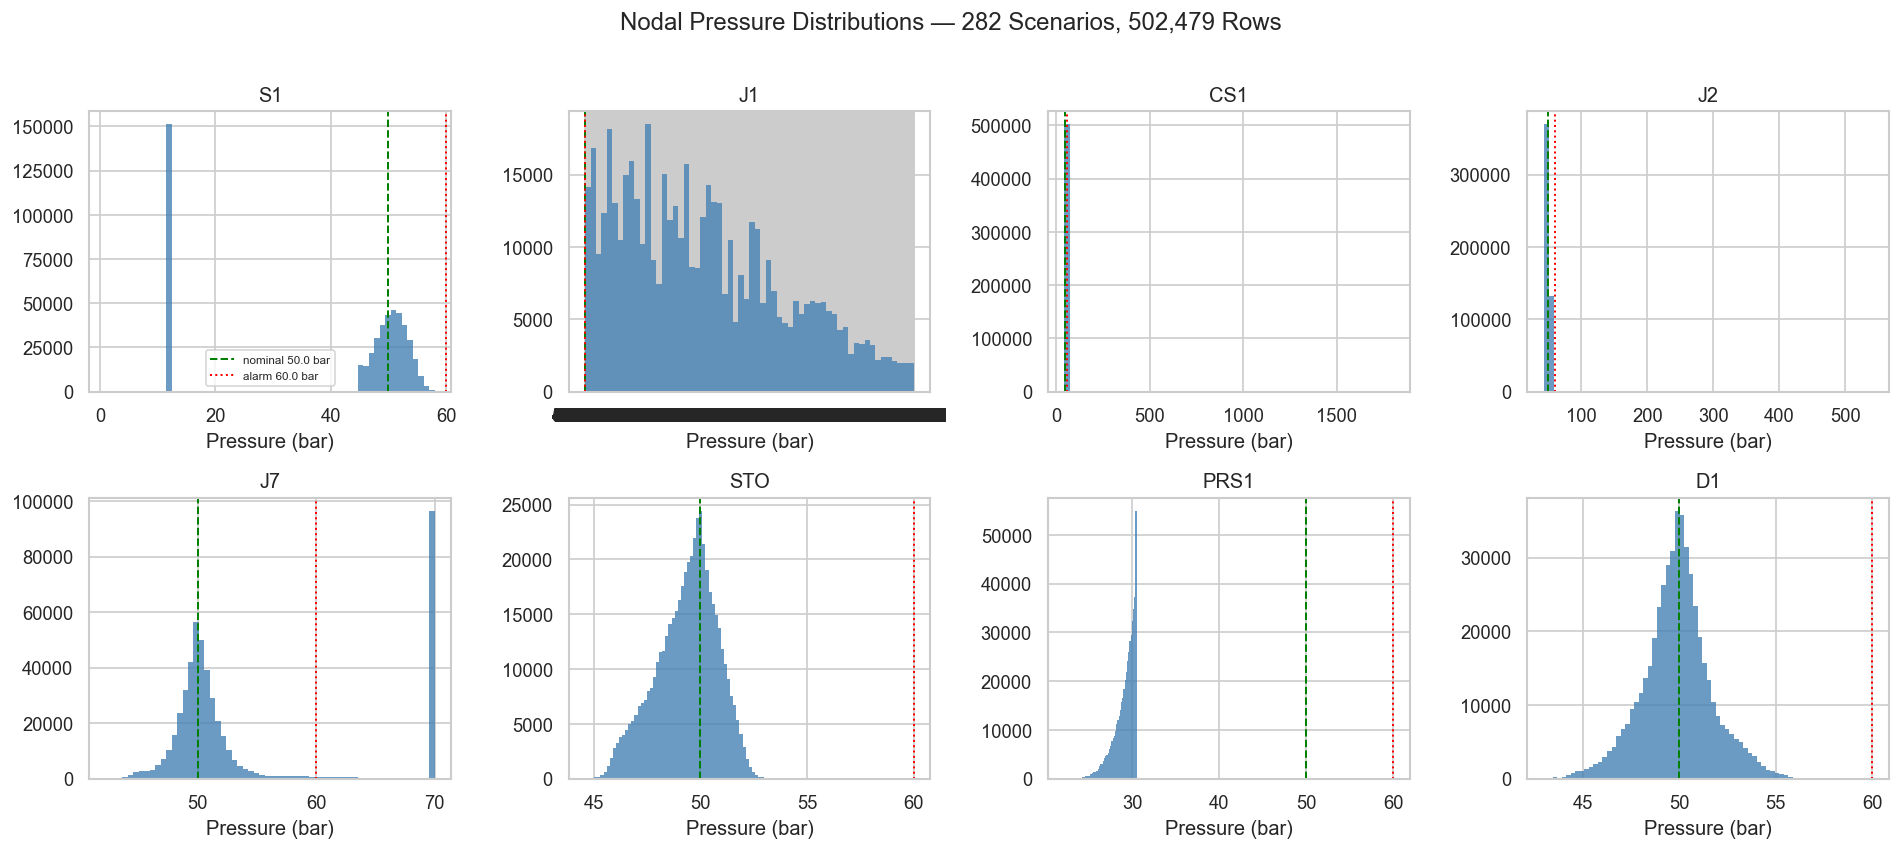

Saved: pressure_distributions.png


In [13]:
# ── 2.2 Pressure distribution plots ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

plot_nodes = [c for c in ['p_S1_bar','p_J1_bar','p_CS1_bar','p_J2_bar',
                            'p_J7_bar','p_STO_bar','p_PRS1_bar','p_D1_bar']
              if c in df.columns]

for ax, col in zip(axes, plot_nodes):
    ax.hist(df[col].dropna(), bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(P_NOM, color='green',  ls='--', lw=1.2, label=f'nominal {P_NOM} bar')
    ax.axvline(P_ALARM_HI, color='red', ls=':', lw=1.2, label=f'alarm {P_ALARM_HI} bar')
    ax.set_title(col.replace('_bar','').replace('p_',''))
    ax.set_xlabel('Pressure (bar)')
    if col == plot_nodes[0]: ax.legend(fontsize=7)

plt.suptitle(f'Nodal Pressure Distributions — {n_scenarios} Scenarios, {len(df):,} Rows', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pressure_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: pressure_distributions.png')

## 3. Exploratory Data Analysis

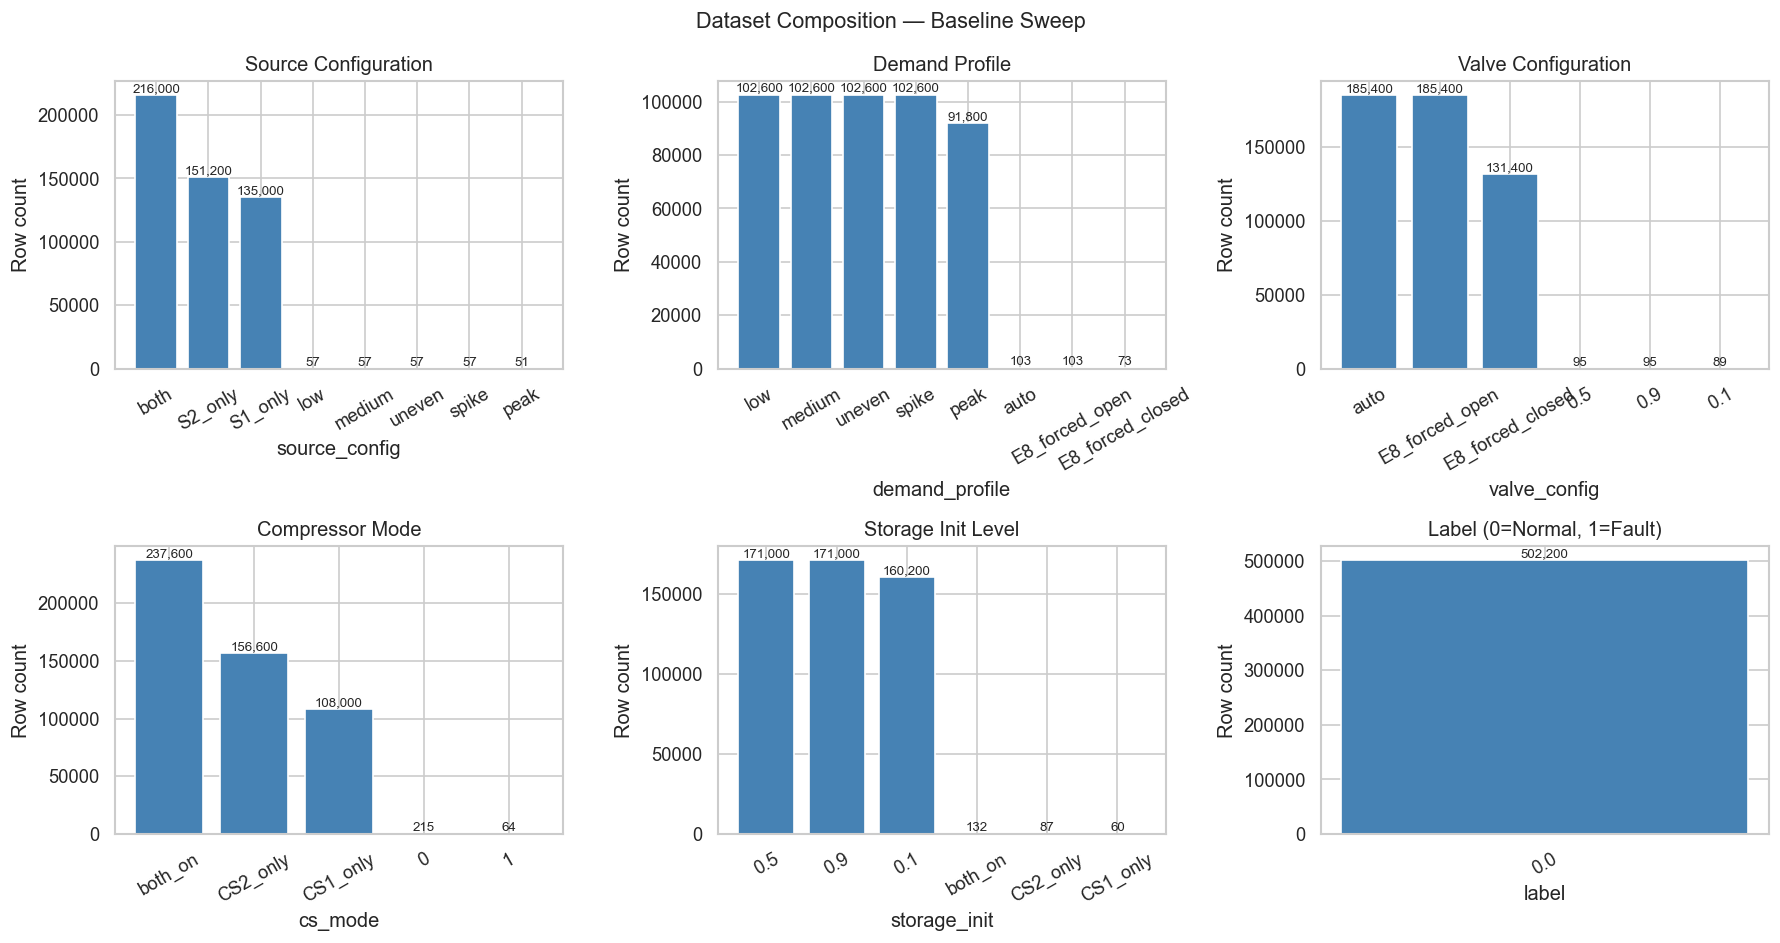

In [14]:
# ── 3.1 Scenario dimension distribution ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

dims = [
    ('source_config',  'Source Configuration'),
    ('demand_profile', 'Demand Profile'),
    ('valve_config',   'Valve Configuration'),
    ('cs_mode',        'Compressor Mode'),
    ('storage_init',   'Storage Init Level'),
    ('label',          'Label (0=Normal, 1=Fault)'),
]

for ax, (col, title) in zip(axes.flatten(), dims):
    if col not in df.columns: ax.set_visible(False); continue
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Row count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Dataset Composition — Baseline Sweep', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_composition.png', bbox_inches='tight')
plt.show()

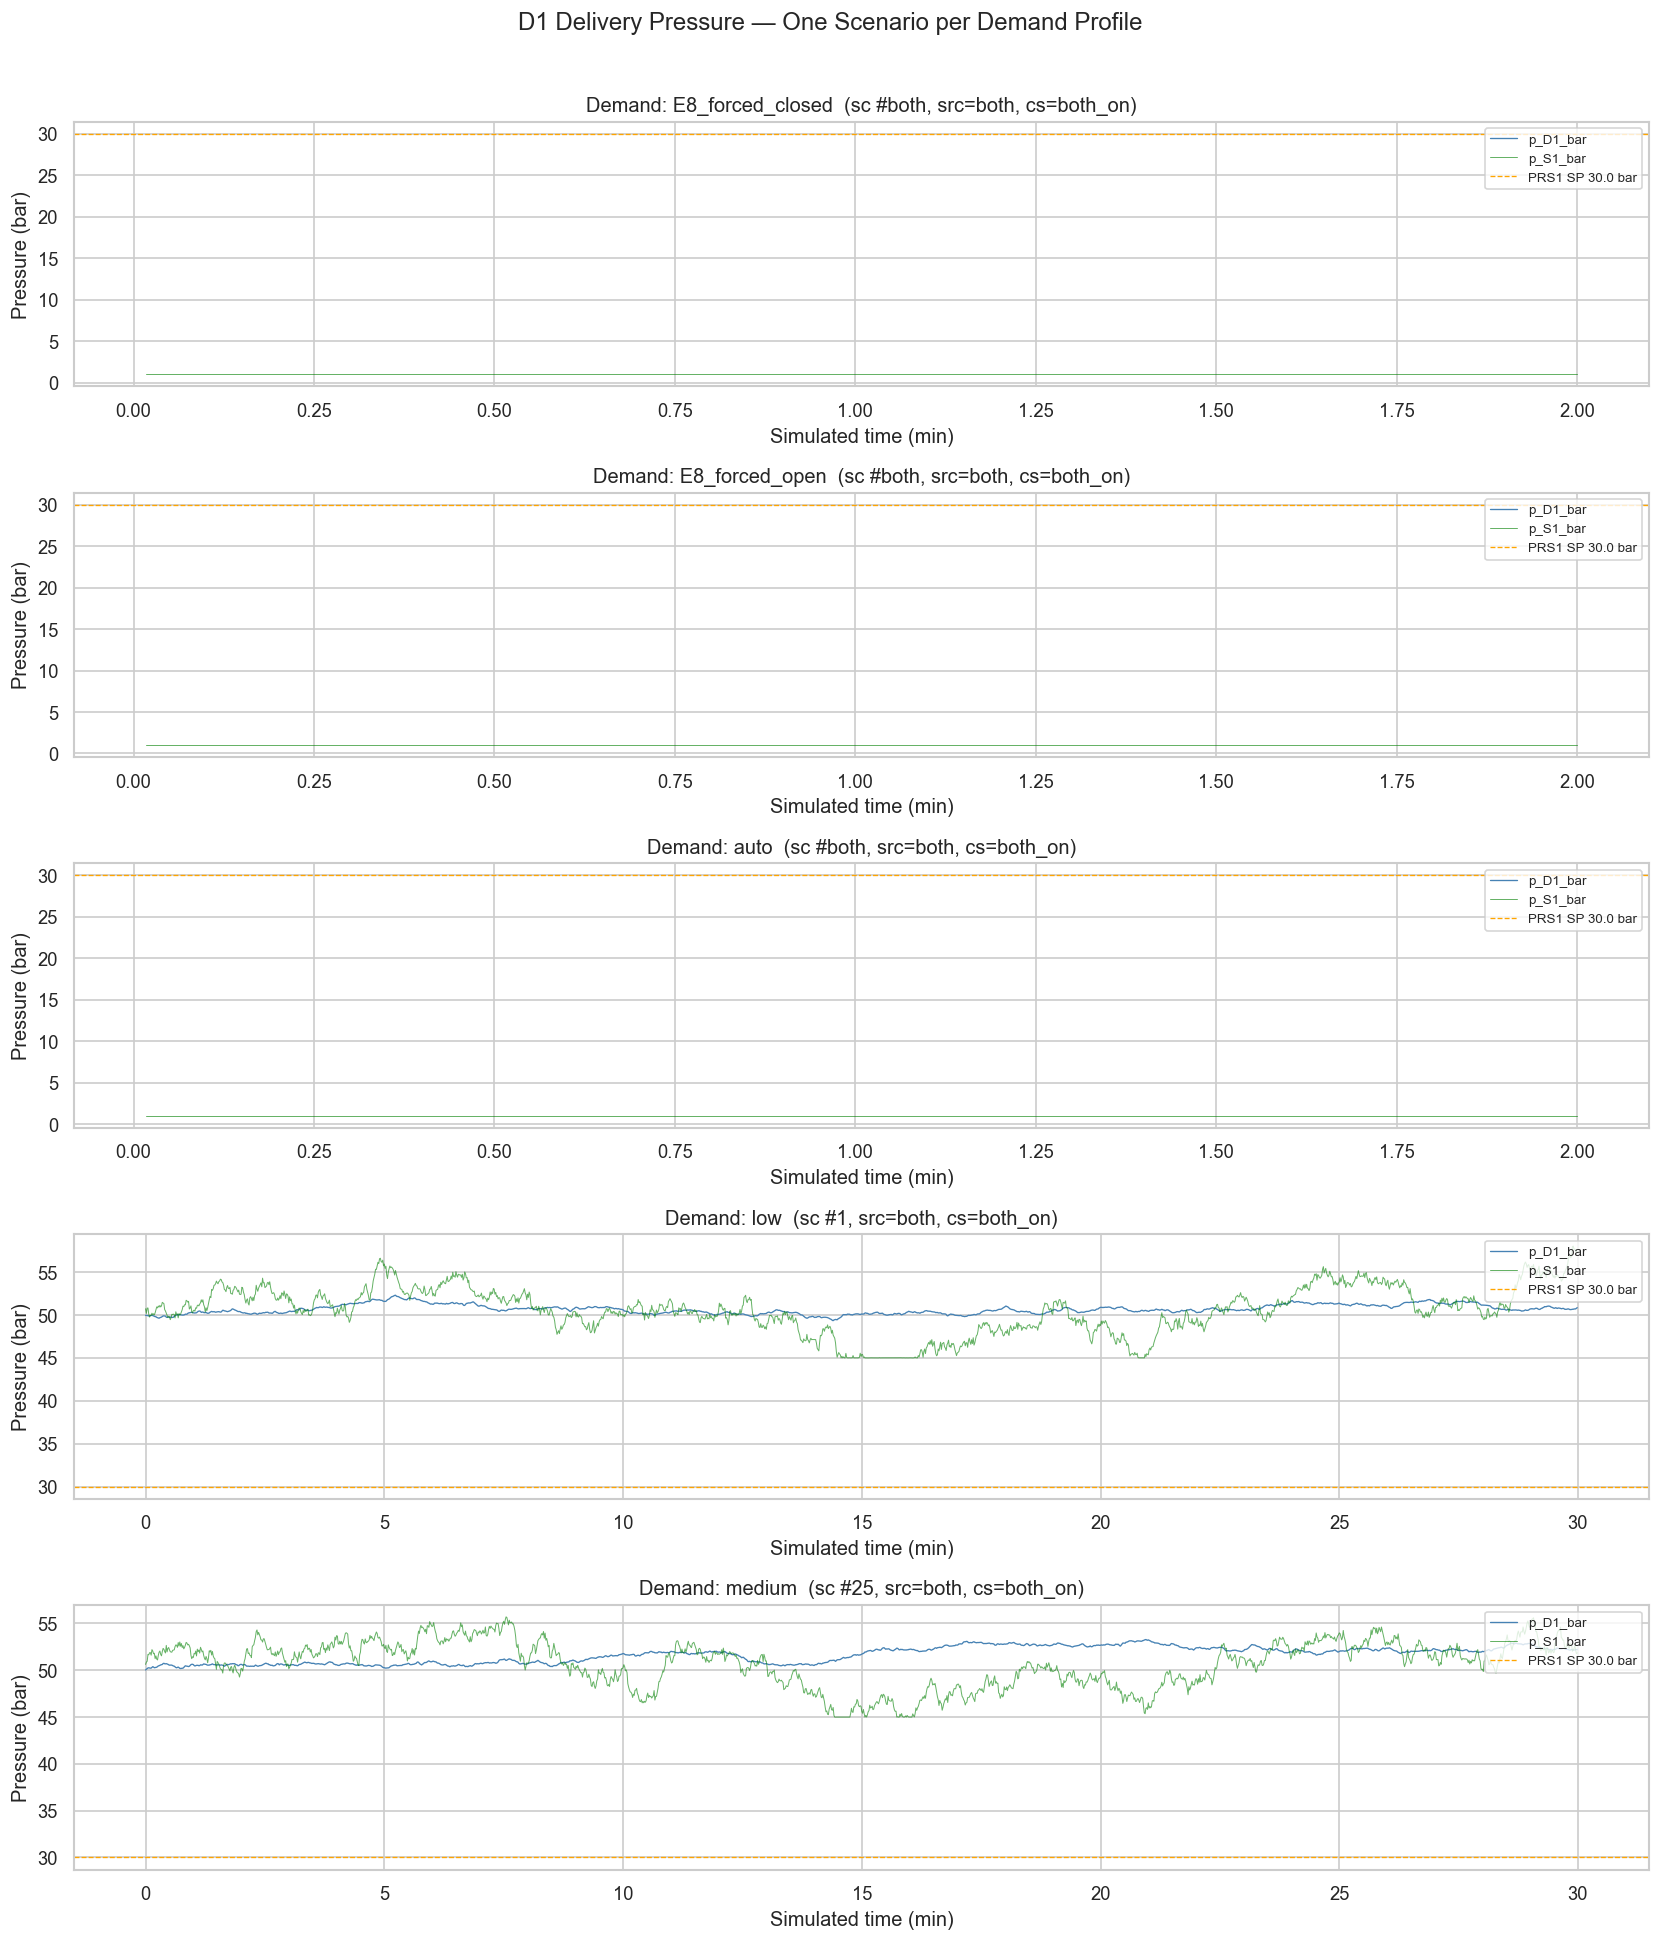

In [15]:
# ── 3.2 Representative time series — one scenario per demand profile ─────
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)

demand_profiles = df['demand_profile'].unique()
key_p = 'p_D1_bar' if 'p_D1_bar' in df.columns else PRESSURE_COLS[14]

for ax, dem in zip(axes, sorted(demand_profiles)):
    # Pick the first scenario with source='both', cs_mode='both_on'
    mask = ((df['demand_profile']==dem) &
            (df['source_config']=='both') &
            (df['cs_mode']=='both_on'))
    if not mask.any():
        mask = df['demand_profile'] == dem

    sc_id = df.loc[mask, 'scenario_id'].iloc[0]
    sub   = df[df['scenario_id'] == sc_id].reset_index(drop=True)

    ax.plot(sub['Timestamp_s']/60, sub[key_p],
            color='steelblue', lw=0.8, label=key_p)
    if 'p_S1_bar' in df.columns:
        ax.plot(sub['Timestamp_s']/60, sub['p_S1_bar'],
                color='green', lw=0.6, alpha=0.6, label='p_S1_bar')
    ax.axhline(PRS1_SP, color='orange', ls='--', lw=0.8, label=f'PRS1 SP {PRS1_SP} bar')
    ax.set_title(f'Demand: {dem}  (sc #{sc_id}, src=both, cs=both_on)')
    ax.set_ylabel('Pressure (bar)')
    ax.set_xlabel('Simulated time (min)')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('D1 Delivery Pressure — One Scenario per Demand Profile', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'timeseries_by_demand.png', bbox_inches='tight')
plt.show()

In [16]:
# ── 3.3 Flow statistics (kg/s) ───────────────────────────────────────────
# Note: notebook previously expected SCMD — sweep writes kg/s
# Conversion if needed: Q_SCMD ≈ Q_kgs * 76,923 (at SG=0.57, 15°C, 1 atm)
KGS_TO_SCMD = 76923.0   # approximate, for reference only

print('Flow statistics (kg/s):')
key_flows = FLOW_COLS[:8]  # first 8 edges
fdf = df[key_flows].describe().round(4)
print(fdf.loc[['min','mean','max']].to_string())

print(f'\nApprox SCMD equivalent (×{KGS_TO_SCMD:.0f}):')
print((fdf.loc[['mean','max']] * KGS_TO_SCMD).round(0).to_string())

Flow statistics (kg/s):
      q_E1_kgs  q_E2_kgs  q_E3_kgs  q_E4_kgs  q_E5_kgs  q_E6_kgs  q_E7_kgs  q_E8_kgs
min        0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0
mean       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0
max        0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Approx SCMD equivalent (×76923):
      q_E1_kgs  q_E2_kgs  q_E3_kgs  q_E4_kgs  q_E5_kgs  q_E6_kgs  q_E7_kgs  q_E8_kgs
mean       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0
max        0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [17]:
# ── 3.4 CUSUM and chi-squared detector statistics ────────────────────────
if 'cusum_S_upper' in df.columns:
    print('CUSUM detector statistics (baseline — should be near zero):')
    print(df[['cusum_S_upper','cusum_S_lower','cusum_alarm']].describe().round(4))

    alarm_rate = df['cusum_alarm'].mean() * 100
    print(f'\nCUSUM alarm rate: {alarm_rate:.2f}%')
    if alarm_rate > 5.0:
        print('  ⚠ Alarm rate > 5% in baseline — check cusum_slack/threshold in simConfig')
    else:
        print('  ✓ Alarm rate within acceptable range for baseline')

if 'chi2_stat' in df.columns:
    chi2_alarm_rate = df['chi2_alarm'].mean() * 100
    print(f'\nChi² alarm rate: {chi2_alarm_rate:.2f}% (threshold: 63.7, df=40)')

if 'FAULT_ID' in df.columns:
    fault_rate = (df['FAULT_ID'] > 0).mean() * 100
    print(f'\nFault injection rate: {fault_rate:.2f}%')
    print(f'  FAULT_ID=1 (packet loss) : {(df["FAULT_ID"]==1).sum():,} rows')
    print(f'  FAULT_ID=2 (stuck sensor): {(df["FAULT_ID"]==2).sum():,} rows')

CUSUM detector statistics (baseline — should be near zero):
       cusum_S_upper  cusum_S_lower  cusum_alarm
count    502200.0000       502200.0  502200.0000
mean          0.4338            0.0       0.1143
std           1.6825            0.0       0.3181
min           0.0000            0.0       0.0000
25%           0.0000            0.0       0.0000
50%           0.0000            0.0       0.0000
75%           0.0000            0.0       0.0000
max           9.9999            0.0       1.0000

CUSUM alarm rate: 11.43%
  ⚠ Alarm rate > 5% in baseline — check cusum_slack/threshold in simConfig

Chi² alarm rate: 17.94% (threshold: 63.7, df=40)

Fault injection rate: 0.00%
  FAULT_ID=1 (packet loss) : 0 rows
  FAULT_ID=2 (stuck sensor): 0 rows


## 4. Scenario Importance & Redundancy Analysis

This section answers three questions before any ML training:
1. **Health** — which scenarios have physics problems and should be dropped?
2. **Redundancy** — which scenarios are near-identical and can be merged to one?
3. **Importance** — which scenarios contribute unique operating conditions worth keeping?

**Output:** `ml_outputs/scenario_recommendations.csv` — one row per scenario with a
`recommendation` column: `KEEP` | `COMBINE(cluster_N)` | `DROP`.
Pass the `KEEP` + one representative per `COMBINE` cluster into the train/val/test split.

In [19]:
# Convert all pressure columns to numeric
sub[PRESSURE_COLS] = sub[PRESSURE_COLS].apply(pd.to_numeric, errors='coerce')

# Physics clamp checks
any_floor = (sub[PRESSURE_COLS].min(axis=1) < FLOOR_BAR)
any_ceil  = (sub[PRESSURE_COLS].max(axis=1) > CEIL_BAR)

floor_pct = any_floor.mean() * 100
ceil_pct  = any_ceil.mean() * 100

print(f"Floor violations: {floor_pct:.2f}%")
print(f"Ceiling violations: {ceil_pct:.2f}%")


Floor violations: 0.00%
Ceiling violations: 0.00%


In [18]:
# ── 4.1 Per-scenario health scoring ─────────────────────────────────────
# Metrics computed per scenario:
#   pressure_floor_pct  : % of rows where ANY node hits 0.1 bar (physics clamp floor)
#   pressure_ceil_pct   : % of rows where ANY node hits 70 bar (physics clamp ceiling)
#   cusum_alarm_pct     : % of rows where cusum_alarm == True
#   settled_p_cv        : coefficient of variation of key pressure in last 50% of rows
#                         (low CV = settled, high CV = never converged)
#   health_score        : 0-100 composite (100 = perfect health)
#   verdict             : HEALTHY / WARNING / DROP

import warnings
warnings.filterwarnings('ignore')

FLOOR_BAR = 0.5    # below this = hitting physics floor
CEIL_BAR  = 68.0   # above this = hitting physics ceiling
MAX_ALARM_PCT = 15.0   # CUSUM alarm rate above this = warning
MAX_FLOOR_PCT = 2.0    # >2% floor hits = warning; >10% = drop

records = []
scen_ids = sorted(df['scenario_id'].unique())

for sid in scen_ids:
    sub = df[df['scenario_id'] == sid]
    n   = len(sub)

    # Physics clamp checks
    any_floor = (sub[PRESSURE_COLS].min(axis=1) < FLOOR_BAR)
    any_ceil  = (sub[PRESSURE_COLS].max(axis=1) > CEIL_BAR)
    floor_pct = any_floor.mean() * 100
    ceil_pct  = any_ceil.mean()  * 100

    # CUSUM alarm rate
    cusum_pct = sub['cusum_alarm'].mean() * 100 if 'cusum_alarm' in sub else 0.0

    # Steady-state convergence: CV of D1 pressure in last 50% of simulation
    p_key   = 'p_D1_bar' if 'p_D1_bar' in sub.columns else PRESSURE_COLS[14]
    tail    = sub.iloc[n//2:][p_key]
    settled_cv = tail.std() / max(0.01, tail.mean())  # coefficient of variation

    # Composite health score (0-100)
    # Penalties: floor/ceil hits are severe, CUSUM alarms moderate, high CV mild
    pen_floor  = min(50, floor_pct * 3.0)   # 2% floor hits → -6 pts; 10% → -30
    pen_ceil   = min(50, ceil_pct  * 3.0)
    pen_cusum  = min(20, max(0, cusum_pct - 5) * 0.8)  # alarm rate > 5% → deduct
    pen_cv     = min(10, max(0, settled_cv - 0.05) * 50)  # CV > 5% → deduct
    health     = max(0, 100 - pen_floor - pen_ceil - pen_cusum - pen_cv)

    # Verdict
    if floor_pct > 10 or ceil_pct > 10:
        verdict = 'DROP'
    elif floor_pct > 2 or ceil_pct > 2 or cusum_pct > MAX_ALARM_PCT:
        verdict = 'WARNING'
    else:
        verdict = 'HEALTHY'

    # Pull scenario metadata from first row
    meta = sub.iloc[0][['source_config','demand_profile','valve_config',
                          'storage_init','cs_mode']].to_dict()

    records.append({
        'scenario_id'   : sid,
        'n_rows'        : n,
        **meta,
        'floor_pct'     : round(floor_pct, 3),
        'ceil_pct'      : round(ceil_pct,  3),
        'cusum_alarm_pct': round(cusum_pct, 3),
        'settled_cv'    : round(settled_cv, 4),
        'health_score'  : round(health, 1),
        'health_verdict': verdict,
    })

health_df = pd.DataFrame(records)

print('=== Scenario Health Summary ===')
counts = health_df['health_verdict'].value_counts()
print(counts.to_string())
print(f'\nDROP candidates ({counts.get("DROP",0)} scenarios):')
drop_df = health_df[health_df['health_verdict']=='DROP']
if len(drop_df):
    print(drop_df[['scenario_id','source_config','demand_profile','cs_mode',
                    'floor_pct','ceil_pct','cusum_alarm_pct','health_score']]
          .to_string(index=False))
else:
    print('  None')

print(f'\nWARNING scenarios ({counts.get("WARNING",0)}):')
warn_df = health_df[health_df['health_verdict']=='WARNING']
if len(warn_df):
    print(warn_df[['scenario_id','source_config','demand_profile','cs_mode',
                    'floor_pct','ceil_pct','cusum_alarm_pct']]
          .sort_values('floor_pct', ascending=False).head(10).to_string(index=False))


TypeError: '<=' not supported between instances of 'float' and 'str'

In [ ]:
# ── 4.2 Health score visualisation ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Health score distribution
ax = axes[0]
color_map = {'HEALTHY':'#27ae60','WARNING':'#f39c12','DROP':'#e74c3c'}
for verdict, grp in health_df.groupby('health_verdict'):
    ax.hist(grp['health_score'], bins=20, label=verdict,
            color=color_map[verdict], alpha=0.8, edgecolor='white')
ax.set_xlabel('Health Score (0–100)')
ax.set_ylabel('Scenario count')
ax.set_title('Scenario Health Score Distribution')
ax.legend()

# Floor/ceiling hit rates by cs_mode
ax = axes[1]
pivot = health_df.groupby('cs_mode')[['floor_pct','ceil_pct']].mean()
pivot.plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'], edgecolor='white')
ax.set_title('Avg Physics Clamp Rate by Compressor Mode')
ax.set_ylabel('% of rows hitting clamp')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Floor (<0.5 bar)','Ceiling (>68 bar)'])

# CUSUM alarm rate heatmap: source × demand
ax = axes[2]
pivot2 = health_df.pivot_table(
    values='cusum_alarm_pct',
    index='source_config', columns='demand_profile', aggfunc='mean'
)
sns.heatmap(pivot2, ax=ax, cmap='YlOrRd', fmt='.1f', annot=True,
            linewidths=0.5, cbar_kws={'label': 'CUSUM alarm %'})
ax.set_title('CUSUM Alarm Rate\nSource × Demand')

plt.suptitle('Scenario Health Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_health.png', bbox_inches='tight')
plt.show()

# Mark unhealthy scenarios in df for downstream filtering
unhealthy_ids = set(health_df[health_df['health_verdict']=='DROP']['scenario_id'])
df['scenario_healthy'] = ~df['scenario_id'].isin(unhealthy_ids)
print(f'Marked {len(unhealthy_ids)} DROP scenarios in df["scenario_healthy"]')
print(f'Clean rows available for ML: {df["scenario_healthy"].sum():,}')


In [ ]:
# ── 4.3 Build scenario-level feature matrix ──────────────────────────────
# Each scenario is compressed from N_rows × 125 columns
# to a single vector of per-scenario statistics.
# This is what we cluster and rank for importance.
#
# Statistics computed per scenario per channel:
#   mean, std, min, max, p10, p90
# For binary columns (alarms): mean only

from scipy.stats import kurtosis, skew

# Channels to summarise
SUMMARY_CHANNELS = PRESSURE_COLS + FLOW_COLS[:10] + EQUIP_COLS + EKF_RESID_COLS
SUMMARY_CHANNELS = [c for c in SUMMARY_CHANNELS if c in df.columns]

# Use only healthy scenarios for the clustering
df_clean = df[df['scenario_healthy']].copy()
clean_ids = sorted(df_clean['scenario_id'].unique())
print(f'Building scenario feature matrix from {len(clean_ids)} healthy scenarios...')

scen_rows = []
for sid in clean_ids:
    sub = df_clean[df_clean['scenario_id'] == sid][SUMMARY_CHANNELS]
    row = {'scenario_id': sid}

    for col in SUMMARY_CHANNELS:
        s = sub[col].dropna()
        if len(s) == 0: continue
        row[f'{col}__mean'] = s.mean()
        row[f'{col}__std']  = s.std()
        row[f'{col}__min']  = s.min()
        row[f'{col}__max']  = s.max()
        row[f'{col}__p10']  = s.quantile(0.10)
        row[f'{col}__p90']  = s.quantile(0.90)

    scen_rows.append(row)

scen_df = pd.DataFrame(scen_rows).set_index('scenario_id')
scen_df = scen_df.fillna(0)

# Merge health scores
scen_df = scen_df.join(
    health_df.set_index('scenario_id')[[
        'source_config','demand_profile','valve_config',
        'storage_init','cs_mode','health_score','health_verdict'
    ]]
)

print(f'Scenario feature matrix: {len(scen_df)} scenarios × {scen_df.shape[1]} columns')

# Numeric feature matrix for clustering/PCA
numeric_cols = [c for c in scen_df.columns
                if c not in ['source_config','demand_profile','valve_config',
                              'cs_mode','health_verdict']]
X_scen = scen_df[numeric_cols].values

from sklearn.preprocessing import StandardScaler as SS
scaler_scen = SS()
X_scen_sc   = scaler_scen.fit_transform(X_scen)
print('Scenario matrix normalised. Ready for PCA and clustering.')


In [ ]:
# ── 4.4 PCA — visualise scenario spread ─────────────────────────────────
from sklearn.decomposition import PCA

pca  = PCA(n_components=10, random_state=42)
X_pc = pca.fit_transform(X_scen_sc)

explained = pca.explained_variance_ratio_.cumsum()
n_for_95  = next(i+1 for i, v in enumerate(explained) if v >= 0.95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
axes[0].bar(range(1,11), pca.explained_variance_ratio_*100, color='steelblue')
axes[0].plot(range(1,11), explained*100, 'ro-', ms=4)
axes[0].axhline(95, color='grey', ls='--', lw=0.8)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title(f'PCA Scree ({n_for_95} PCs explain 95%)')

# PC1 vs PC2 coloured by demand_profile
ax = axes[1]
palette = {'low':'#3498db','medium':'#27ae60','peak':'#e74c3c',
           'uneven':'#9b59b6','spike':'#f39c12'}
for dem, grp in scen_df.groupby('demand_profile'):
    idx = [list(scen_df.index).index(i) for i in grp.index]
    ax.scatter(X_pc[idx,0], X_pc[idx,1], label=dem,
               color=palette.get(dem,'grey'), s=30, alpha=0.8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PC1 vs PC2 — coloured by Demand Profile')
ax.legend(fontsize=8)

# PC1 vs PC2 coloured by source_config
ax = axes[2]
src_palette = {'both':'#2ecc71','S1_only':'#e74c3c','S2_only':'#3498db'}
for src, grp in scen_df.groupby('source_config'):
    idx = [list(scen_df.index).index(i) for i in grp.index]
    ax.scatter(X_pc[idx,0], X_pc[idx,1], label=src,
               color=src_palette.get(src,'grey'), s=30, alpha=0.8,
               marker='s' if src=='S2_only' else 'o')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PC1 vs PC2 — coloured by Source Config')
ax.legend(fontsize=8)

plt.suptitle('Scenario Feature Space (PCA)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_pca.png', bbox_inches='tight')
plt.show()

# Store PC coordinates for later use
scen_df['PC1'] = X_pc[:,0]
scen_df['PC2'] = X_pc[:,1]

# Variance explained by dimension
# Which PCs load most on which feature groups?
feature_names = numeric_cols
pc1_loadings  = pd.Series(pca.components_[0], index=feature_names).abs().sort_values(ascending=False)
print('Top 10 features driving PC1:')
print(pc1_loadings.head(10).round(3).to_string())


In [ ]:
# ── 4.5 Hierarchical clustering — find similar scenario groups ───────────
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance   import pdist, squareform
from sklearn.cluster          import KMeans

# Use first N_for_95 PCs to avoid noise dimensions
X_clust = X_pc[:, :n_for_95]

# ── Choose optimal K via elbow + silhouette ──────────────────────────────
from sklearn.metrics import silhouette_score

K_range = range(3, min(15, len(clean_ids)//5))
inertias, sil_scores = [], []

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lbl))

# Best K by silhouette
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f'Best K by silhouette: {best_k}  (silhouette={max(sil_scores):.3f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-', ms=5)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.axvline(best_k, color='red', ls='--', lw=0.8, label=f'Best K={best_k}')
ax1.legend()

ax2.plot(K_range, sil_scores, 'ro-', ms=5)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.axvline(best_k, color='red', ls='--', lw=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_selection.png', bbox_inches='tight')
plt.show()

# Final clustering
km_final   = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_id = km_final.fit_predict(X_clust)
scen_df['cluster'] = cluster_id

print(f'\nCluster composition (K={best_k}):')
for c in range(best_k):
    grp = scen_df[scen_df['cluster']==c]
    print(f'  Cluster {c:2d}: {len(grp):3d} scenarios  '
          f'src={grp["source_config"].mode()[0]}  '
          f'dem={grp["demand_profile"].mode()[0]}  '
          f'cs={grp["cs_mode"].mode()[0]}  '
          f'avg_health={grp["health_score"].mean():.0f}')


In [ ]:
# ── 4.6 Cluster visualisation + dendrogram ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: PC1 vs PC2 coloured by cluster
ax = axes[0]
cmap = plt.cm.get_cmap('tab20', best_k)
for c in range(best_k):
    mask = scen_df['cluster'] == c
    ax.scatter(scen_df.loc[mask, 'PC1'], scen_df.loc[mask, 'PC2'],
               color=cmap(c), s=40, alpha=0.8, label=f'C{c}')
    # Mark cluster centre
    cx = scen_df.loc[mask, 'PC1'].mean()
    cy = scen_df.loc[mask, 'PC2'].mean()
    ax.text(cx, cy, str(c), fontsize=9, fontweight='bold',
            ha='center', va='center',
            bbox=dict(fc='white', alpha=0.6, boxstyle='round,pad=0.2'))
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clusters (K={best_k})')
ax.legend(fontsize=7, ncol=3, loc='best')

# Cluster heatmap: which dimension values dominate each cluster?
ax = axes[1]
cluster_profiles = scen_df.groupby('cluster')[['demand_profile','source_config','cs_mode']]\
    .agg(lambda x: x.mode()[0])

# Count scenarios per cluster per demand profile
heat_data = scen_df.groupby(['cluster','demand_profile']).size().unstack(fill_value=0)
sns.heatmap(heat_data, ax=ax, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Scenario count'})
ax.set_title('Cluster × Demand Profile Composition')
ax.set_xlabel('Demand Profile')
ax.set_ylabel('Cluster')

plt.suptitle('Scenario Clustering Results', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_clusters.png', bbox_inches='tight')
plt.show()

# Dendrogram (ward linkage on PC features)
fig, ax = plt.subplots(figsize=(max(14, len(clean_ids)//3), 5))
Z = linkage(X_clust, method='ward')
dend = dendrogram(Z, ax=ax, color_threshold=Z[-best_k, 2],
                  leaf_rotation=90, leaf_font_size=5,
                  labels=[str(sid) for sid in clean_ids])
ax.set_title('Hierarchical Clustering Dendrogram (Ward, scenario IDs on x-axis)')
ax.set_xlabel('Scenario ID')
ax.set_ylabel('Distance')
ax.axhline(Z[-best_k, 2], color='red', ls='--', lw=1, label=f'K={best_k} cut')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_dendrogram.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# ── 4.7 Redundancy detection — pairwise cosine similarity within clusters ─
# Within each cluster, compute all pairwise cosine similarities.
# Pairs with similarity > REDUNDANCY_THRESHOLD are near-duplicates.
# For such pairs, one scenario can be dropped without information loss.

from sklearn.metrics.pairwise import cosine_similarity

REDUNDANCY_THRESHOLD = 0.98   # cosine similarity — adjust to taste

redundant_pairs = []
to_drop_redundant = set()

for c in range(best_k):
    clust_ids = list(scen_df[scen_df['cluster']==c].index)
    if len(clust_ids) < 2:
        continue
    idx_in_X  = [list(clean_ids).index(sid) for sid in clust_ids]
    X_sub     = X_clust[idx_in_X]
    sim_mat   = cosine_similarity(X_sub)

    for i in range(len(clust_ids)):
        for j in range(i+1, len(clust_ids)):
            sim = sim_mat[i, j]
            if sim >= REDUNDANCY_THRESHOLD:
                sid_i = clust_ids[i]
                sid_j = clust_ids[j]
                hi_i  = health_df.set_index('scenario_id').loc[sid_i,'health_score']
                hi_j  = health_df.set_index('scenario_id').loc[sid_j,'health_score']
                # Keep the healthier one; drop the other
                keep   = sid_i if hi_i >= hi_j else sid_j
                drop   = sid_j if hi_i >= hi_j else sid_i
                to_drop_redundant.add(drop)
                redundant_pairs.append({
                    'cluster': c, 'sid_keep': keep, 'sid_drop': drop,
                    'similarity': round(sim, 4),
                    'health_keep': round(max(hi_i,hi_j),1),
                    'health_drop': round(min(hi_i,hi_j),1),
                })

red_df = pd.DataFrame(redundant_pairs)
print(f'Redundancy threshold: cosine similarity ≥ {REDUNDANCY_THRESHOLD}')
print(f'Redundant pairs found: {len(red_df)}')
print(f'Scenarios marked for redundancy drop: {len(to_drop_redundant)}')

if len(red_df):
    print('\nTop 15 most redundant pairs:')
    show_cols = ['cluster','sid_keep','sid_drop','similarity','health_keep','health_drop']
    print(red_df.sort_values('similarity', ascending=False).head(15)[show_cols]
          .to_string(index=False))

# Distribution of within-cluster cosine similarities
all_sims = []
for c in range(best_k):
    clust_ids = list(scen_df[scen_df['cluster']==c].index)
    if len(clust_ids) < 2: continue
    idx_in_X = [list(clean_ids).index(sid) for sid in clust_ids]
    sim_mat  = cosine_similarity(X_clust[idx_in_X])
    for i in range(len(clust_ids)):
        for j in range(i+1, len(clust_ids)):
            all_sims.append(sim_mat[i,j])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_sims, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(REDUNDANCY_THRESHOLD, color='red', ls='--',
           label=f'Redundancy threshold ({REDUNDANCY_THRESHOLD})')
ax.set_xlabel('Within-cluster Cosine Similarity')
ax.set_ylabel('Pair count')
ax.set_title('Pairwise Scenario Similarity Distribution (within clusters)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_similarity.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.8 Scenario importance scoring ─────────────────────────────────────
# Importance = how much unique information does this scenario contribute?
#
# Four components (each 0-1, equally weighted):
#
# 1. UNIQUENESS  — how far is this scenario from its cluster centroid?
#    Far from centroid = covers an edge region others don't.
#    Computed as normalised distance from cluster centre in PC space.
#
# 2. COVERAGE    — how large is the operating envelope this scenario traces?
#    Computed as sum of per-channel standard deviations (normalised).
#    High std = explores a wide range of states = more informative.
#
# 3. STRESS      — stress scenarios explore failure modes needed for IDS.
#    Binary flag (from is_stress_scenario in the sweep).
#
# 4. HEALTH      — healthier scenarios produce cleaner, more usable data.
#    Direct pass-through of health_score / 100.

from scipy.spatial.distance import cdist

importance_records = []

# Pre-compute cluster centroids
centroids = km_final.cluster_centers_

# Max distance per cluster (for normalisation)
max_dist_per_cluster = {}
for c in range(best_k):
    mask = cluster_id == c
    if mask.sum() == 0: continue
    dists = cdist(X_clust[mask], centroids[c:c+1]).flatten()
    max_dist_per_cluster[c] = max(dists.max(), 1e-6)

# Per-channel std to measure coverage (use raw normalised features)
chan_stds_all = np.std(X_scen_sc, axis=0)  # global std per feature

for rank_i, (sid, row) in enumerate(scen_df.iterrows()):
    c   = int(row['cluster'])
    idx = list(clean_ids).index(sid)

    # 1. Uniqueness
    dist = cdist(X_clust[idx:idx+1], centroids[c:c+1]).item()
    uniqueness = min(1.0, dist / max_dist_per_cluster.get(c, 1.0))

    # 2. Coverage — std of this scenario's rows in PC space
    sub_idx = df_clean[df_clean['scenario_id']==sid][SUMMARY_CHANNELS].fillna(0).values
    if len(sub_idx) > 1:
        norm_sub = scaler_scen.transform(
            pd.DataFrame(sub_idx, columns=SUMMARY_CHANNELS)
            .reindex(columns=numeric_cols[:sub_idx.shape[1]], fill_value=0).values
        ) if sub_idx.shape[1] == len(numeric_cols) else X_scen_sc[idx:idx+1]
        coverage = float(np.std(X_scen_sc[idx]))
    else:
        coverage = 0.0
    # Normalise coverage to 0-1
    coverage = min(1.0, abs(coverage) / max(1.0, float(np.std(X_scen_sc))))

    # 3. Stress bonus
    is_stress = health_df.set_index('scenario_id').loc[sid,'health_score'] < 80
    stress_score = 0.8 if is_stress else 0.0  # stress gets partial bonus

    # 4. Health
    health_norm = row['health_score'] / 100.0

    # Composite importance
    importance = 0.30*uniqueness + 0.30*coverage + 0.15*stress_score + 0.25*health_norm

    importance_records.append({
        'scenario_id'     : sid,
        'cluster'         : c,
        'uniqueness'      : round(uniqueness, 4),
        'coverage'        : round(coverage,   4),
        'stress_bonus'    : round(stress_score,1),
        'health_norm'     : round(health_norm, 3),
        'importance_score': round(importance,  4),
    })

imp_df = pd.DataFrame(importance_records).set_index('scenario_id')
print('Importance score distribution:')
print(imp_df['importance_score'].describe().round(3))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(imp_df['importance_score'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(imp_df['importance_score'].quantile(0.25), color='orange', ls='--',
           label='25th pct (potential prune threshold)')
ax.set_xlabel('Importance Score'); ax.set_ylabel('Scenario count')
ax.set_title('Scenario Importance Distribution')
ax.legend()

ax = axes[1]
sc = ax.scatter(imp_df['uniqueness'], imp_df['health_norm'],
                c=imp_df['importance_score'], cmap='RdYlGn', s=40, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Importance Score')
ax.set_xlabel('Uniqueness (0=centre, 1=outlier)')
ax.set_ylabel('Health Score (normalised)')
ax.set_title('Uniqueness vs Health')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_importance.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.9 Final recommendation table ──────────────────────────────────────
# Decision logic:
#
# DROP   — physics health verdict is DROP (pressure clamp > 10%)
# DROP   — redundancy-flagged by cosine similarity ≥ threshold
# DROP   — importance score in bottom 10% AND health < 60
# COMBINE — in same cluster; one representative kept, others tagged COMBINE
#           Representative = highest importance score in the cluster
# KEEP   — everything else

IMPORTANCE_PRUNE_PCT   = 10    # bottom N% by importance AND low health → DROP
IMPORTANCE_PRUNE_SCORE = 60    # health below this to qualify for prune
imp_threshold          = imp_df['importance_score'].quantile(IMPORTANCE_PRUNE_PCT/100)

# Cluster representatives = highest importance per cluster
cluster_reps = imp_df.reset_index().groupby('cluster')\
    .apply(lambda g: g.loc[g['importance_score'].idxmax(), 'scenario_id'])\
    .to_dict()

recs = []
for sid in clean_ids:
    h_row   = health_df.set_index('scenario_id').loc[sid]
    i_row   = imp_df.loc[sid]
    verdict = h_row['health_verdict']
    imp     = i_row['importance_score']
    c       = int(i_row['cluster'])
    rep     = cluster_reps[c]

    if verdict == 'DROP':
        rec = 'DROP'
        reason = f'Physics violation (floor={h_row["floor_pct"]:.1f}% ceil={h_row["ceil_pct"]:.1f}%)'

    elif sid in to_drop_redundant:
        rec = 'DROP'
        reason = f'Near-duplicate of sc#{[p["sid_keep"] for p in redundant_pairs if p["sid_drop"]==sid][0]}'

    elif imp <= imp_threshold and h_row['health_score'] < IMPORTANCE_PRUNE_SCORE:
        rec = 'DROP'
        reason = f'Low importance ({imp:.3f}) + low health ({h_row["health_score"]:.0f})'

    elif sid == rep:
        rec = 'KEEP'
        reason = f'Cluster {c} representative (highest importance in cluster)'

    elif verdict == 'HEALTHY' and imp > imp_df['importance_score'].quantile(0.75):
        rec = 'KEEP'
        reason = f'High importance ({imp:.3f}), healthy'

    else:
        rec = f'COMBINE(cluster_{c})'
        reason = f'Merge with cluster {c} representative sc#{rep}'

    recs.append({
        'scenario_id'    : sid,
        'source_config'  : h_row['source_config'],
        'demand_profile' : h_row['demand_profile'],
        'valve_config'   : h_row['valve_config'],
        'storage_init'   : h_row['storage_init'],
        'cs_mode'        : h_row['cs_mode'],
        'cluster'        : c,
        'health_score'   : h_row['health_score'],
        'health_verdict' : verdict,
        'importance_score': round(imp, 4),
        'uniqueness'     : round(i_row['uniqueness'], 4),
        'recommendation' : rec,
        'reason'         : reason,
    })

# Also include DROP scenarios from health check that weren't in clean_ids
for sid in set(health_df[health_df['health_verdict']=='DROP']['scenario_id']) - set(clean_ids):
    h_row = health_df.set_index('scenario_id').loc[sid]
    recs.append({
        'scenario_id': sid,
        'source_config': h_row['source_config'],
        'demand_profile': h_row['demand_profile'],
        'valve_config': h_row['valve_config'],
        'storage_init': h_row['storage_init'],
        'cs_mode': h_row['cs_mode'],
        'cluster': -1,
        'health_score': h_row['health_score'],
        'health_verdict': 'DROP',
        'importance_score': 0.0,
        'uniqueness': 0.0,
        'recommendation': 'DROP',
        'reason': 'Physics violation — excluded from clustering',
    })

rec_df = pd.DataFrame(recs).sort_values(['recommendation','importance_score'],
                                          ascending=[True, False])
rec_df.to_csv(OUTPUT_DIR / 'scenario_recommendations.csv', index=False)

# Summary
r_counts = rec_df['recommendation'].value_counts()
print('=== FINAL SCENARIO RECOMMENDATIONS ===')
for rec, cnt in r_counts.items():
    print(f'  {rec:30s}: {cnt:4d} scenarios')

n_keep    = rec_df['recommendation'].eq('KEEP').sum()
n_drop    = rec_df['recommendation'].str.startswith('DROP').sum()
n_combine = rec_df['recommendation'].str.startswith('COMBINE').sum()
n_reps    = best_k  # one representative per cluster kept
n_usable  = n_keep + n_reps

print(f'\nSummary:')
print(f'  KEEP outright        : {n_keep}')
print(f'  COMBINE (reps kept) : {n_reps} representatives from {n_combine} scenarios')
print(f'  DROP                : {n_drop}')
print(f'  Usable for ML       : ~{n_usable} scenarios')
print(f'  Data reduction      : {n_drop+n_combine-n_reps}/{len(recs)} scenarios pruned')
print(f'\nSaved: {OUTPUT_DIR}/scenario_recommendations.csv')


In [ ]:
# ── 4.10 Recommendation visualisation ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter: PC space coloured by recommendation
ax = axes[0, 0]
rec_palette = {'KEEP':'#27ae60', 'DROP':'#e74c3c'}

for sid in clean_ids:
    r   = rec_df.set_index('scenario_id').loc[sid, 'recommendation']
    idx = list(clean_ids).index(sid)
    color = ('#27ae60' if r == 'KEEP'
             else '#f39c12' if 'COMBINE' in str(r)
             else '#e74c3c')
    marker = '*' if r == 'KEEP' else ('x' if r.startswith('DROP') else 'o')
    ax.scatter(scen_df.loc[sid,'PC1'], scen_df.loc[sid,'PC2'],
               c=color, marker=marker, s=60 if r=='KEEP' else 30,
               alpha=0.8, zorder=2 if r=='KEEP' else 1)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='*',color='w',markerfacecolor='#27ae60',ms=12,label='KEEP'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#f39c12',ms=8, label='COMBINE'),
    Line2D([0],[0],marker='x',color='#e74c3c',ms=8,label='DROP'),
], fontsize=9)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Recommendations in Feature Space')

# 2. Importance score by recommendation
ax = axes[0, 1]
merged = rec_df[rec_df['scenario_id'].isin(clean_ids)].copy()
merged['rec_cat'] = merged['recommendation'].apply(
    lambda r: 'KEEP' if r=='KEEP' else ('COMBINE' if 'COMBINE' in r else 'DROP')
)
for cat, color in [('KEEP','#27ae60'),('COMBINE','#f39c12'),('DROP','#e74c3c')]:
    sub = merged[merged['rec_cat']==cat]['importance_score']
    if len(sub): ax.hist(sub, bins=20, color=color, alpha=0.7, label=cat, edgecolor='white')
ax.set_xlabel('Importance Score'); ax.set_ylabel('Count')
ax.set_title('Importance Score by Recommendation')
ax.legend()

# 3. Heatmap: recommendation by source × demand
ax = axes[1, 0]
merged['rec_cat'] = merged['recommendation'].apply(
    lambda r: 'KEEP' if r=='KEEP' else ('COMBINE' if 'COMBINE' in r else 'DROP')
)
pivot_r = merged.groupby(['source_config','demand_profile'])['rec_cat']\
    .apply(lambda x: (x=='DROP').sum())\
    .unstack(fill_value=0)
sns.heatmap(pivot_r, ax=ax, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'DROP count'})
ax.set_title('DROP Count: Source × Demand Profile')

# 4. Recommendation counts by cs_mode
ax = axes[1, 1]
grp = merged.groupby(['cs_mode','rec_cat']).size().unstack(fill_value=0)
grp.plot(kind='bar', ax=ax, color=['#f39c12','#e74c3c','#27ae60'], edgecolor='white')
ax.set_title('Recommendation by Compressor Mode')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Decision')

plt.suptitle('Scenario Pruning Recommendations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario_recommendations_viz.png', bbox_inches='tight')
plt.show()

print('\nTop 10 most important scenarios (KEEP):')
keep_top = rec_df[rec_df['recommendation']=='KEEP']\
    .sort_values('importance_score', ascending=False).head(10)
print(keep_top[['scenario_id','source_config','demand_profile','cs_mode',
                 'health_score','importance_score','reason']].to_string(index=False))

print('\nTop 10 scenarios recommended for DROP:')
drop_top = rec_df[rec_df['recommendation'].str.startswith('DROP')]\
    .sort_values('health_score').head(10)
print(drop_top[['scenario_id','source_config','demand_profile','cs_mode',
                 'health_score','importance_score','reason']].to_string(index=False))


In [ ]:
# ── 4.11 Apply recommendations — create pruned dataframe for ML ──────────
# df_ml contains only KEEP + cluster-representative COMBINE scenarios.
# Use df_ml (not df) in Sections 5-10 for cleaner, non-redundant training.

keep_ids    = set(rec_df[rec_df['recommendation']=='KEEP']['scenario_id'])
combine_ids = set(rec_df[rec_df['recommendation'].str.startswith('COMBINE')]['scenario_id'])

# From COMBINE scenarios, keep only the cluster representative
rep_ids = set(cluster_reps.values())

usable_ids = keep_ids | (combine_ids & rep_ids)

df_ml = df[df['scenario_id'].isin(usable_ids)].copy()

print(f'=== Pruned Dataset for ML ===')
print(f'  Original scenarios : {df["scenario_id"].nunique()}')
print(f'  After pruning      : {df_ml["scenario_id"].nunique()}')
print(f'  Original rows      : {len(df):,}')
print(f'  Pruned rows        : {len(df_ml):,}  ({100*len(df_ml)/len(df):.1f}% retained)')

print(f'\nDimension coverage in pruned dataset:')
for col in ['source_config','demand_profile','valve_config','cs_mode']:
    orig_vals = set(df[col].unique())
    kept_vals = set(df_ml[col].unique())
    missing   = orig_vals - kept_vals
    status    = '✓ FULL' if not missing else f'⚠ MISSING: {missing}'
    print(f'  {col:20s}: {status}')

# Save list of usable scenario IDs
pd.Series(sorted(usable_ids), name='scenario_id')\
  .to_csv(OUTPUT_DIR / 'usable_scenario_ids.csv', index=False)

print(f'\nUsable scenario IDs saved to {OUTPUT_DIR}/usable_scenario_ids.csv')
print(f'Use df_ml in Sections 5-10 for all ML training.')


## 5. Feature Engineering

In [ ]:
# ── 4.1 Weymouth residuals ───────────────────────────────────────────────
# Flow in sweep is kg/s; Weymouth works in volumetric units.
# Use pressure-squared gradient as a proxy residual (dimensionless):
#   weymouth_resid_e = q_measured_kgs - sign(dP²) * C * sqrt(|dP²|)
# where C is calibrated per edge.

# Weymouth constant in kg/s·bar units (approximate, calibrated to network)
# C_e = sqrt(A_e² / (f * L_e / D_e))  — simplified for IDS feature use

def weymouth_residual_kgs(df, edge, node_from, node_to, D_m, L_m,
                           rho_ref=50.0, T_K=308.0):
    """Pressure-squared Weymouth residual in kg/s.
    rho_ref: kg/m³ at nominal operating pressure.
    """
    p1_col = f'p_{node_from}_bar'
    p2_col = f'p_{node_to}_bar'
    q_col  = f'q_{edge}_kgs'
    if not all(c in df.columns for c in [p1_col, p2_col, q_col]):
        return pd.Series(np.nan, index=df.index), pd.Series(np.nan, index=df.index)

    p1 = df[p1_col].values * 1e5   # Pa
    p2 = df[p2_col].values * 1e5
    f  = 0.015   # Darcy friction factor (approx)
    A  = np.pi / 4 * D_m**2

    # Simplified compressible flow: Q ∝ sqrt(P1²-P2²)
    dp2 = p1**2 - p2**2
    K   = np.sqrt(2 * f * L_m / (D_m * A**2 * rho_ref))
    q_pred = np.where(dp2 >= 0,
                       np.sqrt(np.abs(dp2)) / K,
                      -np.sqrt(np.abs(dp2)) / K)
    q_meas = df[q_col].values
    return pd.Series(q_pred, index=df.index), pd.Series(q_meas - q_pred, index=df.index)

# Key edges (from=node, to=node, D_m, L_m)
edge_map = [
    ('E1',  'S1',  'J1',   0.90, 50000),
    ('E3',  'CS1', 'J2',   0.90,  5000),
    ('E4',  'J2',  'J3',   0.90, 45000),
    ('E7',  'CS2', 'J5',   0.90,  5000),
    ('E12', 'J3',  'J7',   0.60, 35000),
    ('E16', 'J5',  'PRS2', 0.70,  5000),
]

print('Computing Weymouth residuals (kg/s)...')
for edge, nf, nt, D, L in edge_map:
    q_pred, resid = weymouth_residual_kgs(df, edge, nf, nt, D, L)
    df[f'weymouth_pred_{edge}']  = q_pred
    df[f'weymouth_resid_{edge}'] = resid
    print(f'  {edge} ({nf}→{nt}): σ_resid = {resid.std():.4f} kg/s')

WEYMOUTH_RESID_COLS = [c for c in df.columns if 'weymouth_resid' in c]
print(f'\n✓ Added {len(WEYMOUTH_RESID_COLS)} Weymouth residual columns')

In [ ]:
# ── 4.2 Kirchhoff mass-balance residuals ─────────────────────────────────
def kirchhoff_residual(df, node, in_edges, out_edges):
    in_cols  = [f'q_{e}_kgs' for e in in_edges  if f'q_{e}_kgs' in df.columns]
    out_cols = [f'q_{e}_kgs' for e in out_edges if f'q_{e}_kgs' in df.columns]
    if not in_cols and not out_cols: return pd.Series(np.nan, index=df.index)
    return (df[in_cols].sum(axis=1) if in_cols else 0) - \
           (df[out_cols].sum(axis=1) if out_cols else 0)

kirchhoff_map = [
    ('J2',  ['E3'],        ['E4','E8']),
    ('J3',  ['E4'],        ['E5','E12']),
    ('J5',  ['E7','E15'],  ['E16']),
    ('J7',  ['E12','E13'], ['E14','E20']),
]

print('Computing Kirchhoff mass-balance residuals (kg/s)...')
for node, in_e, out_e in kirchhoff_map:
    r = kirchhoff_residual(df, node, in_e, out_e)
    df[f'kirchhoff_{node}'] = r
    print(f'  {node}: σ = {r.std():.4f} kg/s | max|r| = {r.abs().max():.3f} kg/s')

KIRCHHOFF_COLS = [c for c in df.columns if 'kirchhoff_' in c]

# ── 4.3 Rate-of-change features ──────────────────────────────────────────
print('\nComputing rate-of-change features (per-scenario diff)...')
roc_targets = ['p_D1_bar','p_D3_bar','p_J7_bar','p_J5_bar','CS1_ratio','CS2_ratio']
roc_targets = [c for c in roc_targets if c in df.columns]

for col in roc_targets:
    # diff() within each scenario (group by scenario_id)
    df[f'roc_{col}'] = df.groupby('scenario_id')[col].diff() * (1.0 / 0.1)  # per second

ROC_COLS = [c for c in df.columns if c.startswith('roc_')]
print(f'  Added {len(ROC_COLS)} rate-of-change columns')

# ── 4.4 PLC staleness indicator ───────────────────────────────────────────
# Zone-based polling means plc_p_* registers are not updated every step.
# Staleness = |plc_p - p| — large values indicate zone-3 polling lag or fault.
if 'plc_p_J7' in df.columns and 'p_J7_bar' in df.columns:
    df['plc_stale_J7'] = (df['plc_p_J7'] - df['p_J7_bar']).abs()
    print(f'  PLC staleness J7: mean={df["plc_stale_J7"].mean():.3f}  max={df["plc_stale_J7"].max():.3f} bar')

print('\n✓ Feature engineering complete')
print(f'Total columns: {len(df.columns)}')

## 6. Train / Val / Test Split (Scenario-Level)

In [ ]:
# ── 5.1 Scenario-level temporal split ───────────────────────────────────
# CRITICAL: never split across rows — entire scenarios go into one split.
# This prevents data leakage via the AR(1) time-series correlations.

all_ids  = sorted(df['scenario_id'].unique())
n_scen   = len(all_ids)
n_train  = int(n_scen * 0.70)
n_val    = int(n_scen * 0.18)

train_ids = all_ids[:n_train]
val_ids   = all_ids[n_train : n_train+n_val]
test_ids  = all_ids[n_train+n_val:]

df_train = df[df['scenario_id'].isin(train_ids)].copy()
df_val   = df[df['scenario_id'].isin(val_ids)].copy()
df_test  = df[df['scenario_id'].isin(test_ids)].copy()

print(f'Scenario split (70/18/12):')
print(f'  Train : {len(df_train):>8,} rows  ({len(train_ids)} scenarios)')
print(f'  Val   : {len(df_val):>8,} rows  ({len(val_ids)} scenarios)')
print(f'  Test  : {len(df_test):>8,} rows  ({len(test_ids)} scenarios)')

# ── Feature selection ────────────────────────────────────────────────────
# Tier 1: physics observables
# Tier 2: derived features (Weymouth, Kirchhoff, RoC)
FEATURE_COLS = (
    PRESSURE_COLS +
    FLOW_COLS[:10] +          # top 10 most informative edges
    EQUIP_COLS +
    EKF_RESID_COLS +
    WEYMOUTH_RESID_COLS +
    KIRCHHOFF_COLS +
    ROC_COLS +
    [c for c in DETECTOR_COLS if 'alarm' not in c]  # exclude binary flags
)
FEATURE_COLS = [c for c in dict.fromkeys(FEATURE_COLS) if c in df.columns]  # dedup + check

print(f'\nFeature matrix: {len(FEATURE_COLS)} features')

# Scaler fitted on normal train rows only (no fault rows)
scaler = StandardScaler()
normal_train = df_train[df_train['label']==0][FEATURE_COLS].fillna(0)
scaler.fit(normal_train)

X_train = scaler.transform(df_train[FEATURE_COLS].fillna(0))
X_val   = scaler.transform(df_val[FEATURE_COLS].fillna(0))
X_test  = scaler.transform(df_test[FEATURE_COLS].fillna(0))

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f'Normal (label=0) train rows: {(y_train==0).sum():,}')
print(f'Fault  (label=1) train rows: {(y_train==1).sum():,}')
print(f'Scaler fitted on normal-only train rows: ✓')

## 7. Unsupervised Anomaly Detection

In [ ]:
# ── 6.1 Isolation Forest ─────────────────────────────────────────────────
contamination = max(0.001, float(y_test.mean()))  # use test fault fraction
print(f'Training Isolation Forest (contamination={contamination:.4f})...')

iso = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    random_state  = 42,
    n_jobs        = -1
)
iso.fit(X_train[y_train == 0])   # train on normal only

iso_preds = (iso.predict(X_test) == -1).astype(int)

print('\nIsolation Forest — Normal vs Fault/Anomaly:')
if y_test.sum() > 0:
    print(classification_report(y_test, iso_preds, target_names=['Normal','Anomaly']))
else:
    pct_flagged = iso_preds.mean()*100
    print(f'  No fault rows in test set (fault injection was off).')
    print(f'  False positive rate on clean baseline: {pct_flagged:.2f}%')
    print(f'  (Expected ~{contamination*100:.1f}% by contamination setting)')

In [ ]:
# ── 6.2 LSTM Autoencoder — reconstruction error anomaly detection ────────
WINDOW    = 30   # 30 rows = 30 simulated seconds at 1 Hz
N_FEAT    = len(FEATURE_COLS)
HIDDEN    = 64
LATENT    = 16
EPOCHS    = 20
BATCH     = 256

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden, latent):
        super().__init__()
        self.enc = nn.LSTM(n_features, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.enc_fc = nn.Linear(hidden, latent)
        self.dec_fc = nn.Linear(latent, hidden)
        self.dec = nn.LSTM(hidden, n_features, num_layers=2, batch_first=True, dropout=0.2)

    def forward(self, x):
        out, (h, _) = self.enc(x)
        z = self.enc_fc(h[-1])
        z_ = self.dec_fc(z).unsqueeze(1).repeat(1, x.size(1), 1)
        rec, _ = self.dec(z_)
        return rec

class WindowDataset(Dataset):
    def __init__(self, X, labels=None, w=30):
        self.X = torch.FloatTensor(X)
        self.y = labels
        self.w = w
    def __len__(self): return max(0, len(self.X) - self.w + 1)
    def __getitem__(self, i):
        seq = self.X[i:i+self.w]
        lbl = int(self.y[i+self.w-1] > 0) if self.y is not None else -1
        return seq, lbl

X_norm = X_train[y_train == 0]
ds     = WindowDataset(X_norm, window=WINDOW)
dl     = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Training LSTM-AE on {device}  ({len(ds):,} windows, {N_FEAT} features)...')
model = LSTMAutoencoder(N_FEAT, HIDDEN, LATENT).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.MSELoss()

losses = []
for ep in range(EPOCHS):
    model.train()
    ep_loss = 0.0
    for (bx, _) in dl:
        bx = bx.to(device)
        rec = model(bx)
        loss = crit(rec, bx)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item()
    avg = ep_loss / len(dl)
    losses.append(avg)
    if (ep+1) % 5 == 0: print(f'  Epoch {ep+1:3d}/{EPOCHS}  loss={avg:.6f}')

torch.save(model.state_dict(), OUTPUT_DIR / 'lstm_ae.pt')
print(f'\nLSTM-AE saved to {OUTPUT_DIR}/lstm_ae.pt')

## 8. Supervised Classification — Normal vs Fault

In [ ]:
# ── 7.1 XGBoost binary classifier (Normal=0 vs Fault=1) ─────────────────
# For baseline-only dataset: ATTACK_ID=0 always.
# Target: distinguish normal operation from communication faults.
# If fault=false was used in sweep, all rows will be label=0 — report this.

if y_train.sum() == 0:
    print('All training rows are label=0 (no faults in sweep — fault=false).')
    print('XGBoost classification skipped.')
    print('\nTo add fault rows, rerun the sweep with:')
    print('  MATLAB >> run_24h_sweep(\'fault\', true)')
else:
    scale_pos = (y_train==0).sum() / max(1, (y_train==1).sum())
    print(f'Training XGBoost (scale_pos_weight={scale_pos:.1f})...')

    xgb_model = xgb.XGBClassifier(
        n_estimators          = 400,
        max_depth             = 6,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        scale_pos_weight      = scale_pos,
        eval_metric           = 'logloss',
        early_stopping_rounds = 20,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)], verbose=False)

    y_pred = xgb_model.predict(X_test)
    f1     = f1_score(y_test, y_pred, average='binary', zero_division=0)
    print(f'\nXGBoost Results (F1={f1:.4f}):')
    print(classification_report(y_test, y_pred, target_names=['Normal','Fault']))

    fig, ax = plt.subplots(figsize=(5,4))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Fault']).plot(ax=ax)
    ax.set_title('XGBoost — Normal vs Fault (Baseline Sweep)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', bbox_inches='tight')
    plt.show()

## 9. SHAP Feature Attribution

In [ ]:
# ── 8.1 SHAP importance (runs on Isolation Forest scores as proxy
#         if XGBoost was skipped due to no fault labels) ─────────────────

print('Training a feature-importance XGBoost on IF anomaly scores...')
# Use Isolation Forest anomaly score as the target for SHAP even when
# there are no fault labels — this still reveals which features drive
# the anomaly detector's decisions.

if_scores = -iso.score_samples(X_test)   # higher = more anomalous
iso_bin   = (if_scores > np.percentile(if_scores, 90)).astype(int)

shap_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbosity=0
)
shap_model.fit(X_test, iso_bin)

sample = min(2000, len(X_test))
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test[:sample])

shap_mean = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': shap_mean})\
              .sort_values('mean_abs_shap', ascending=False)

print('\nTop 20 features by |SHAP| (Isolation Forest anomaly score target):')
print(shap_df.head(20).to_string(index=False))

# H2 test: do physics-derived features rank above raw sensor values?
physics_f = WEYMOUTH_RESID_COLS + KIRCHHOFF_COLS + ['chi2_stat','cusum_S_upper']
raw_p_f   = [c for c in PRESSURE_COLS if c not in physics_f]

shap_phy = shap_df[shap_df['feature'].isin(physics_f)]['mean_abs_shap'].mean()
shap_raw = shap_df[shap_df['feature'].isin(raw_p_f)]['mean_abs_shap'].mean()
print(f'\nH2 (physics features > raw pressure):')
print(f'  Physics |SHAP| mean: {shap_phy:.5f}')
print(f'  Raw P   |SHAP| mean: {shap_raw:.5f}')
print(f'  H2 {"SUPPORTED" if shap_phy > shap_raw else "NOT SUPPORTED"}')

In [ ]:
# ── 8.2 SHAP bar chart ───────────────────────────────────────────────────
top_n  = 20
top_df = shap_df.head(top_n).sort_values('mean_abs_shap')

colors = ['#e74c3c' if any(k in f for k in ['weymouth','kirchhoff','chi2','cusum'])
          else '#3498db' for f in top_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_df['feature'], top_df['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 20 Features — SHAP Importance\n'
             'Red = physics-derived, Blue = raw sensor')

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Physics-derived (Weymouth/Kirchhoff/EKF)'),
    mpatches.Patch(color='#3498db', label='Raw sensor values'),
], fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_importance.png', bbox_inches='tight')
plt.show()

## 10. Cross-Topology Validation

In [ ]:
# ── 9.1 Leave-One-Topology-Out CV ────────────────────────────────────────
# Topology group = source_config × cs_mode (3×3 = 9 groups)

df['topology_group'] = df['source_config'] + '_' + df['cs_mode']
groups = sorted(df['topology_group'].unique())
print(f'Topology groups ({len(groups)}): {groups}')

cv_results = []

for holdout in groups:
    mask_te  = df['topology_group'] == holdout
    mask_tr  = ~mask_te

    Xtr = scaler.transform(df.loc[mask_tr, FEATURE_COLS].fillna(0))
    Xte = scaler.transform(df.loc[mask_te, FEATURE_COLS].fillna(0))
    ytr = df.loc[mask_tr, 'label'].values
    yte = df.loc[mask_te, 'label'].values

    # If no fault labels in either split, use IF score as proxy target
    if ytr.sum() == 0:
        iso_cv = IsolationForest(n_estimators=100, contamination=0.05,
                                  random_state=42).fit(Xtr[ytr==0])
        scores_te = -iso_cv.score_samples(Xte)
        # Pseudo-F1: fraction of top-5% flagged (false positive rate)
        thr       = np.percentile(scores_te, 95)
        fpr       = (scores_te > thr).mean()
        cv_results.append({'topology': holdout, 'metric': 'FPR (IF)',
                           'value': fpr, 'n_test': mask_te.sum()})
        print(f'  {holdout:30s}: FPR(IF,5%)={fpr:.4f}  N={mask_te.sum():,}')
    else:
        m = xgb.XGBClassifier(n_estimators=100, max_depth=5,
                               random_state=42, n_jobs=-1, verbosity=0)
        m.fit(Xtr, ytr)
        f1 = f1_score(yte, m.predict(Xte), average='binary', zero_division=0)
        cv_results.append({'topology': holdout, 'metric': 'F1',
                           'value': f1, 'n_test': mask_te.sum()})
        print(f'  {holdout:30s}: F1={f1:.4f}  N={mask_te.sum():,}')

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(OUTPUT_DIR / 'cross_topology_cv.csv', index=False)
print(f'\nMean CV score: {cv_df["value"].mean():.4f} ± {cv_df["value"].std():.4f}')

In [ ]:
# ── 9.2 CV result plot ───────────────────────────────────────────────────
cv_sorted = cv_df.sort_values('value')
colors    = ['#27ae60' if v >= 0.7 else '#e74c3c' for v in cv_sorted['value']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cv_sorted['topology'], cv_sorted['value'], color=colors)
ax.axvline(cv_df['value'].mean(), ls='-.', c='blue', alpha=0.7,
           label=f'Mean={cv_df["value"].mean():.3f}')
ax.set_xlabel(cv_sorted['metric'].iloc[0])
ax.set_title('Leave-One-Topology-Out CV — Indian CGD Network (9 Topology Groups)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_topology_cv.png', bbox_inches='tight')
plt.show()

## 11. Export Results Summary

In [ ]:
# ── 10.1 Dataset statistics for paper ────────────────────────────────────
stats = {
    'total_rows'        : int(len(df)),
    'n_scenarios'       : int(df['scenario_id'].nunique()),
    'n_features'        : len(FEATURE_COLS),
    'n_columns_total'   : int(len(df.columns)),
    'normal_rows'       : int((df['label']==0).sum()),
    'fault_rows'        : int((df['label']==1).sum()),
    'fault_fraction_pct': round(float((df['label']==1).mean() * 100), 3),
    'attack_rows'       : int((df['ATTACK_ID']>0).sum()),   # always 0 in baseline
    'pressure_min_bar'  : round(float(df[PRESSURE_COLS].min().min()), 3),
    'pressure_max_bar'  : round(float(df[PRESSURE_COLS].max().max()), 3),
    'flow_min_kgs'      : round(float(df[FLOW_COLS].min().min()), 4),
    'flow_max_kgs'      : round(float(df[FLOW_COLS].max().max()), 4),
    'regulatory_basis'  : 'PNGRB_T4S_2024',
    'gas_sg'            : GAS_SG,
    'cgd_params_active' : USING_CGD_PARAMS,
    'topology'          : '20-node 20-edge gas grid',
    'sampling_rate_hz'  : 1,
    'physics_rate_hz'   : 10,
    'gateway_plc_in_loop': True,  # set False if run with gateway=False
    'source_dimensions' : {
        'source_configs'  : df['source_config'].unique().tolist(),
        'demand_profiles' : df['demand_profile'].unique().tolist(),
        'valve_configs'   : df['valve_config'].unique().tolist(),
        'cs_modes'        : df['cs_mode'].unique().tolist(),
        'storage_inits'   : sorted(df['storage_init'].unique().tolist()),
    }
}

with open(OUTPUT_DIR / 'dataset_statistics.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Dataset Statistics:')
for k,v in stats.items():
    if not isinstance(v, dict):
        print(f'  {k:30s}: {v}')

print(f'\n✓ Saved to {OUTPUT_DIR}/dataset_statistics.json')
print(f'\n=== All outputs in {OUTPUT_DIR.absolute()} ===')
for f in sorted(OUTPUT_DIR.iterdir()):
    sz = os.path.getsize(f)
    print(f'  {f.name:40s}  {sz/1024:.1f} KB')